#### Farouk Khlifi and Adrien Lemercier, Ecole Polytechnique, May 2020

# Project Random Numerical Simulations: Population dynamics 

## Implementation of Importance Sampling techniques (Farouk Khlifi)

Implementing the importance sampling idea on the project:

This notebook is made so the reader can set variables and print convenient graphs, studied in part II of the project

In [1]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool, TimeoutError #Using a pool of workers for parallel simulations.
plt.rcParams['figure.figsize'] = [15, 10]

Problem parameters

In [2]:
m = .7     #averge number of children per individual
n = 10     #nb of generations
pop = 1    #initial population 
#pool=Pool()

In [3]:
#Defining the most interesting events for the part:



def lenteur(c):
    """Returns the sous_exp function that checks wether a trajectory is under c**n"""
    def sous_exp(traj):
        return (traj[-1]>0 and traj[-1]>=c**(len(traj)))
    return sous_exp
def survie(X):
    """Defining the survival event"""
    if X[-1]>0:
        return 1
    return 0

#Defining a maximum resource function

def depasse(x):
    def ressource(X):
        if (np.max(X)>x):
            return 1
        else:
            return 0
    return ressource

def depasse_sum(x):
    def depasse(X):
        if (np.sum(X)>x):
            return 1
        else:
            return 0
    return depasse

In [4]:

def trajectoire(m1,n,pop): #renvoie une trajectoire sans selction pour m=m1
    X=np.zeros(n)
    X[0]=pop
    for i in range(1,n):
        if X[i-1]>0:
            X[i]=np.random.negative_binomial(X[i-1],1/(m1+1))
    return X
def rapport_vraisemblance(m,m1,traj):
    """Returns the likelihood ratio"""
    prod=1
    for i in range(1,len(traj)):
        if traj[i-1]>0:
            prod *= sps.nbinom.pmf(traj[i], traj[i-1],1/(m+1))/sps.nbinom.pmf(traj[i],traj[i-1], 1/(m1+1))
    #print("vraisemblance:", prod)
    return prod
def importance_sampling(n,m,m1,pop,event,size=1000):
    """Does an importance sampling with population the probability change m1, and for event and returns both the mean and std"""

    trajectories=[trajectoire(m1,n,pop) for i in range(size)]
    liste=[event(traj)*rapport_vraisemblance(m,m1,traj) for traj in trajectories]
    #Calcul différent de la variance à activer quand il le faut.
    #liste_var=[event(traj)*rapport_vraisemblance(m,m1,traj)**2 for traj in trajectories]
    return np.mean(liste), np.std(liste)/np.sqrt(size)


def naive_monte_carlo(n,m,pop,event,size=10000):
    """Implements a naive Monte Carlo for m"""
    trajectories=[trajectoire(m,n,pop) for i in range(size)]
    liste=[event(traj) for traj in trajectories]
    return np.mean(liste), np.std(liste)/np.sqrt(size)
def temp():
    return trajectoire(m,n,pop)
"""
def parallel_naive_monte_carlo(n,m,pop, event, size=10000):
   
    trajectories= pool.map( temp, range(size))
    map(survie, trajectories)
    return np.mean(liste), np.std(liste)/np.sqrt(size)"""


def proba_de_survie(n,m):
    "Returns the probability of survival"
    return m**n*(1-m)/(1-m**n)

In [5]:
#Detemenistric calculation of the max resouce probability



def proba_first(k,m):
    """Returns the first probabilities of the first move of the first generation"""
    return (1/(m+1))*(m/(m+1))**k

def proba_depassement(x,n,m,pop=1):
    
    vect_prob=np.zeros(x+1)
    vect_prob[pop]=1
    trans=np.zeros((x+1,x+1))
    trans[0,0]=1
    for i in range(x+1):
        for j in range(1,x+1):
            trans[i][j]=sps.nbinom.pmf(i,j, 1/(m+1) )
    for k in range(n-1):
        vect_prob= np.dot(trans,vect_prob)
    return 1-np.sum(vect_prob)
            
    
def proba_depassement_sum(x,n,m):  
    
    
    vect_prob=np.array([proba_first(k,m) for k in range(x+1)])
    trans=np.zeros((x+1,x+1))
    trans[0,0]=1
    for j in range(x+1):
        for i in range(x+1-j):
            trans[i+j][j]=sps.nbinom.pmf(i,j, 1/(m+1) )
    for k in range(n-1):
        vect_prob= np.dot(trans,vect_prob)
    return 1-np.sum(vect_prob)




In [6]:
#printing the execution time of naive Monte Carlo and the importance sampling method


#Not so rare case 8.10e⁻3

start=time.time()
print("The naive Monte Carlo results" ,naive_monte_carlo(10,.7,1,survie,100000))
print(time.time()-start)

"""
start=time.time()
print("The naive Monte Carlo results" ,parallel_naive_monte_carlo(10,.7,1,survie,100000))
print(time.time()-start)"""

start=time.time()
print("The importance sampling results", importance_sampling(10,.7,1,1,survie,50), proba_de_survie(10,0.7))
print(time.time()-start)




The naive Monte Carlo results (0.01229, 0.0003484100443443041)
0.9084169864654541
The importance sampling results (0.03481126130905073, 0.018167557194743507) 0.008720592627384805
0.03436899185180664


In [7]:

#Rare case 1e⁻6

start=time.time()
print("The naive Monte Carlo standard results" ,naive_monte_carlo(10,.3,1,survie,1000000))
print(time.time()-start)

start=time.time()
print("The importance sampling standard results", importance_sampling(10,.3,1,1,survie,100), proba_de_survie(10,.3))
print(time.time()-start)

The naive Monte Carlo standard results (1.2e-05, 3.4640808304657124e-06)
7.352323770523071
The importance sampling standard results (5.693546144538159e-06, 3.989602184437722e-06) 4.13345440763493e-06
0.07467913627624512


In [8]:

#Defining the event we want to test the Importance Sampling on
event=survie #depasse(x), sous_croissance ... 
m=.7
M1=np.arange(m,3,0.1)   #defining the range on which we want to optimize m'


IS=[importance_sampling(10,m,m1,1,survie) for m1 in M1]

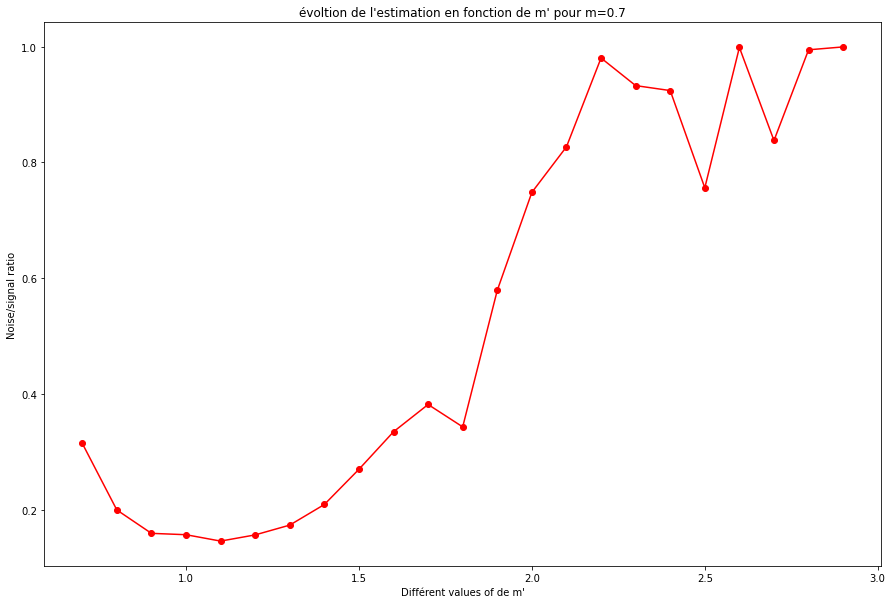

In [9]:

#Plotting the optimisation graph of the importance sampling



plt.xlabel("Différent values of de m'")
plt.ylabel("Noise/signal ratio")

mean,std=[i[0] for i in IS], [i[1] for i in IS]

noise_signal_ratio=np.array(std)/np.array(mean)
plt.title(f"évoltion de l'estimation en fonction de m' pour m={m}")
plt.plot(M1,noise_signal_ratio, "r-o")
plt.savefig("opti")

In [10]:
#Compares the distributution of two estimators 
#Naive Monte Carlo vs m1 distribution importance sampling
m=0.7

naive=importance_sampling(10,m,m,1,survie,size=1000)
imp_sampling= importance_sampling(10,m,1,1,survie,size=1000)



In [11]:
"Given an array X of independant realizations of an estimator, and given a confidence level gamma,"
"the function confidence returns a confidence interval of the estimated quantity"
#assuming normal distribution, is more useful in the interacting particles part where we have a few independent realizations 
#of normal distributed R.Vs

def confidence(X, gamma) :
    l = len(X)
    m = np.mean(X)
#    s = np.sqrt(np.sum((X-m)**2)/(l-1))    #non biaised std
    s = np.std(X)
    q = sps.t.ppf((1+gamma)/2, l-1)   #quantile of Student's t-distribution
    dev = (q*s)/np.sqrt(l)
    return (m, dev, s)

In [12]:
#Doing the same using a parallel computing tool for the exceeding probability 
m=0.7
M=np.arange(0.5,1.5,0.05)

x=5
pool=Pool()
def varying_m(m1):
    print( f"{m1} is done ...")
    return importance_sampling(n+1,m,m1,1,depasse(x),size=100000)
   
preListe= pool.map(varying_m,M)
    


Process ForkPoolWorker-2:
Process ForkPoolWorker-3:
Process ForkPoolWorker-4:
Process ForkPoolWorker-1:
Traceback (most recent call last):


In [13]:

print(proba_depassement(5,10,.7))
print(importance_sampling(10,.7,1,1,depasse(5),size=1000))

In [14]:
stock=np.array(preListe+Liste)
stock=stock[[6,12,20],:].T
plt.axhline(proba_depassement(x,n,m), color="green", label="Proba déterministe ")
plt.boxplot(stock, meanline=True)
plt.legend(loc="best")
plt.title("Box plot of probabilities of exceeding a thereshold x={} before a generation n={} for m={}".format(x,n,m))
plt.xticks(np.arange(1,4), ['0.7(naive)', '1 (optimal)', '1.4'])
plt.savefig("box_plot_facile")

In [15]:
x=35
naive=[]
m=.7
for i in range(500):
    naive.append(importance_sampling(10,m,0.7,1,depasse(x),size=100))
print("naive is done...")
changed=[]
for i in range(500):
    changed.append(importance_sampling(10,m,2,1,depasse(x),size=100))     
print("changed is done...")

In [ ]:
m=0.7
M=np.arange(0.7,2,0.05)
preListe=[[] for i in range(len(M))]
x=30
for k in range(len(M)):
    for i in range(500):
        preListe[k].append(importance_sampling(10,M[k],1,depasse(x),size=100))
    print(f"m={M[k]} is done...")

In [16]:
X=np.arange(10,100)
Theor=[proba_depassement(x,10,0.7) for x in X]
empi=[]
for x in X:
    empi.append(importance_sampling(10,0.7,1,1,depasse(x),size=1000)[0])
    if x%10==0:
        print("{} %".format(x//10*10))


In [17]:
plt.plot(X[:20],empi[:20], "r-o", color="blue", label="Valeurs Monte Carlo")
plt.plot(X[:20],Theor[:20], "r-o", color="green", label="Valeurs Déterministes")
plt.title(r"Varying x and using the probability change with m'=1 to determine $P(max(X_i)>x)$ for different values of x and m=0.7")
plt.ylabel(r"$P(max(X_i)>x)$")
plt.xlabel(" x")
plt.xticks(X[:20])
plt.legend(loc="best")
plt.savefig("Not_so_rare_varying_x")
plt.figure()
plt.plot(X[40:60],empi[40:60],"r-o", color="blue", label="Valeurs Monte Carlo m=1")
plt.plot(X[40:60],Theor[40:60],"r-o", color="green", label="Valeurs Déterministes")
plt.title(r"Bad performance of the probability change with m'=1 to determine $P(max(X_i)>x)$ for different values of x and m=0.7")
plt.ylabel(r"$P(max(X_i)>x)$")
plt.xlabel(" x")
plt.legend(loc="best")
plt.savefig("bad_perf")

In [18]:
empi1=[]
for x in X:
    empi1.append(importance_sampling(10,m,1.5,1,depasse(x),size=1000))
    #print("done for x={}...".format(x))

In [19]:

plt.figure()
plt.plot(X[40:60],empi1[40:60], "r-o", color="b", label="Monte-Carlo avec m'=1.5")
plt.plot(X[40:60],Theor[40:60], "r-o", color="g", label="Déterministe")
plt.legend()
plt.savefig("badperf2")

In [308]:
m=.7
root=[]
#nth root of x
for i in range(100):        
    root.append(importance_sampling(10,1.58,1, depasse(100),size=300))
    print(f"{i} done...")
    
one=[]
for i in range(100):        
    one.append(importance_sampling(10,1,1, depasse(100),size=300))
    print(f"{i} done...")

0 done...
1 done...
2 done...
3 done...
4 done...
5 done...
6 done...
7 done...
8 done...
9 done...
10 done...
11 done...
12 done...
13 done...
14 done...
15 done...
16 done...
17 done...
18 done...
19 done...
20 done...
21 done...
22 done...
23 done...
24 done...
25 done...
26 done...
27 done...
28 done...
29 done...
30 done...
31 done...
32 done...
33 done...
34 done...
35 done...
36 done...
37 done...
38 done...
39 done...
40 done...
41 done...
42 done...
43 done...
44 done...
45 done...
46 done...
47 done...
48 done...
49 done...
50 done...
51 done...
52 done...
53 done...
54 done...
55 done...
56 done...
57 done...
58 done...
59 done...
60 done...
61 done...
62 done...
63 done...
64 done...
65 done...
66 done...
67 done...
68 done...
69 done...
70 done...
71 done...
72 done...
73 done...
74 done...
75 done...
76 done...
77 done...
78 done...
79 done...
80 done...
81 done...
82 done...
83 done...
84 done...
85 done...
86 done...
87 done...
88 done...
89 done...
90 done...
91 done..

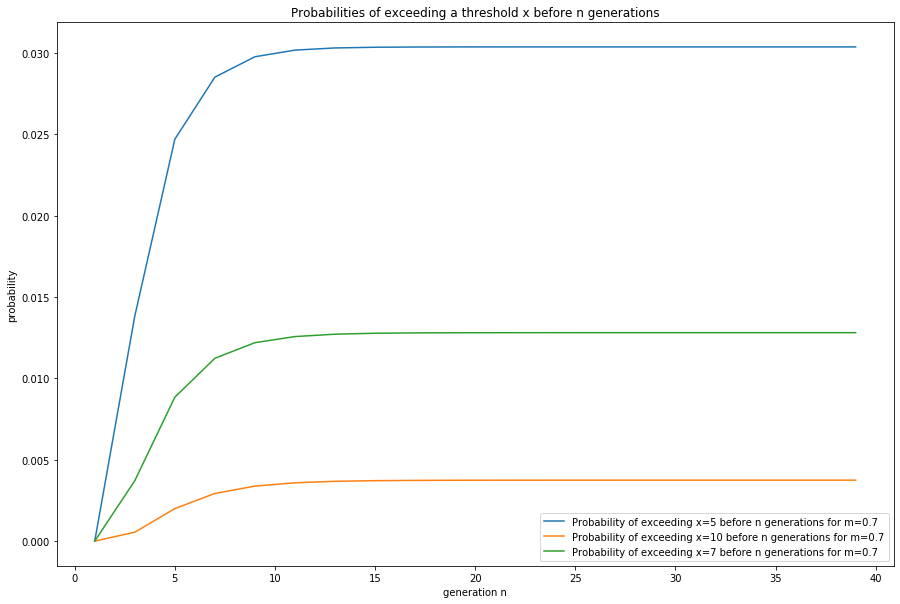

In [652]:
Gen=np.arange(1,40,2)
X=[5,10,7]
for x in X:
    Y=[proba_depassement(x,gen, 0.7,1)   for gen in Gen]
    plt.plot(Gen,Y, label="Probability of exceeding x={} before n generations for m=0.7".format(x))
plt.title("Probabilities of exceeding a threshold x before n generations")
plt.xlabel("generation n")
plt.ylabel("probability")
plt.legend()
plt.savefig("convergence_sorry")

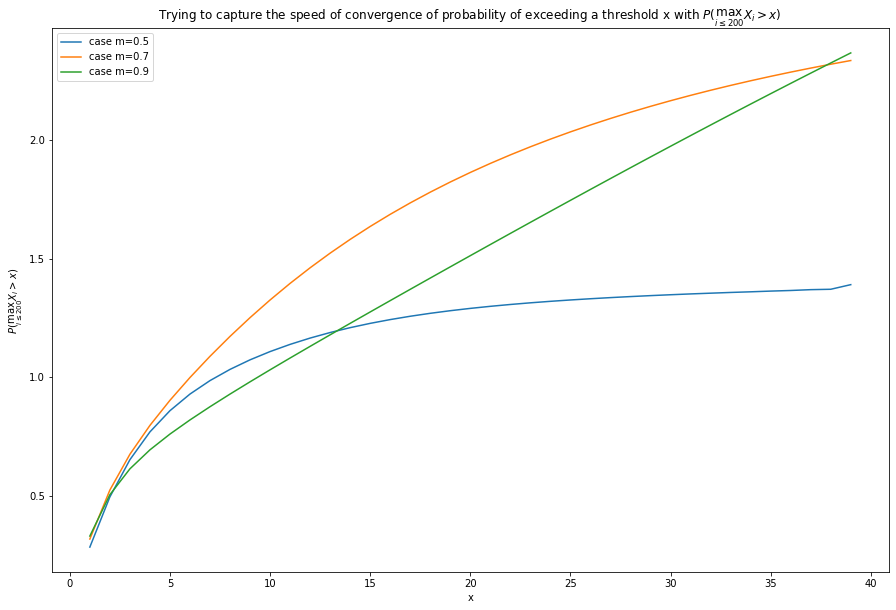

In [24]:
X=np.arange(1,40,1)
M=[0.5,0.7,0.9]
for m in M:
    
    Y=[proba_depassement(x, 200 , m)* m**(-x) *x for x in X]
    plt.plot(X,Y, label="case m={}".format(m))
    
plt.legend()
plt.title("Trying to capture the speed of convergence of probability of exceeding a threshold x with $P(\max_{i \leq 200} X_i> x)$ ") 
plt.xlabel("x")
plt.ylabel("$P(\max_{i \leq 200} X_i> x)$ ")
plt.savefig("speed_m<1")    




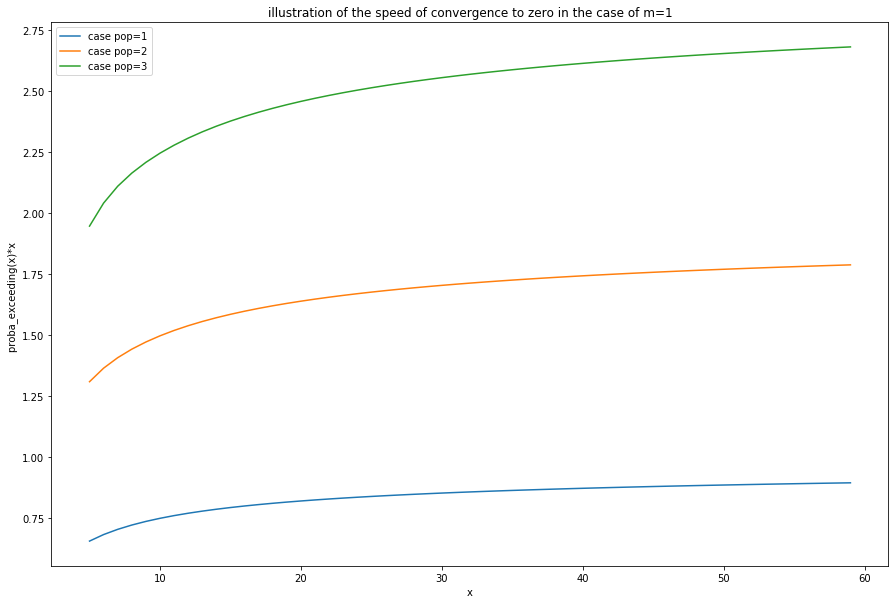

In [650]:
X=np.arange(5,60,1)
POP=[1,2,3]
for pop in POP:

    Y=[proba_depassement(x, 200, 1, pop) *x for x in X]
    plt.plot(X,Y, label="case pop={}".format(pop))
    
plt.legend()
plt.xlabel("x")
plt.ylabel("proba_exceeding(x)*x ")

plt.title("illustration of the speed of convergence to zero in the case of m=1")
plt.savefig("convergence")

In [637]:
proba_depassement(200, 100, m) *200

0.5411916032547204

0.4117645158726766


/home/farouk/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.
  after removing the cwd from sys.path.


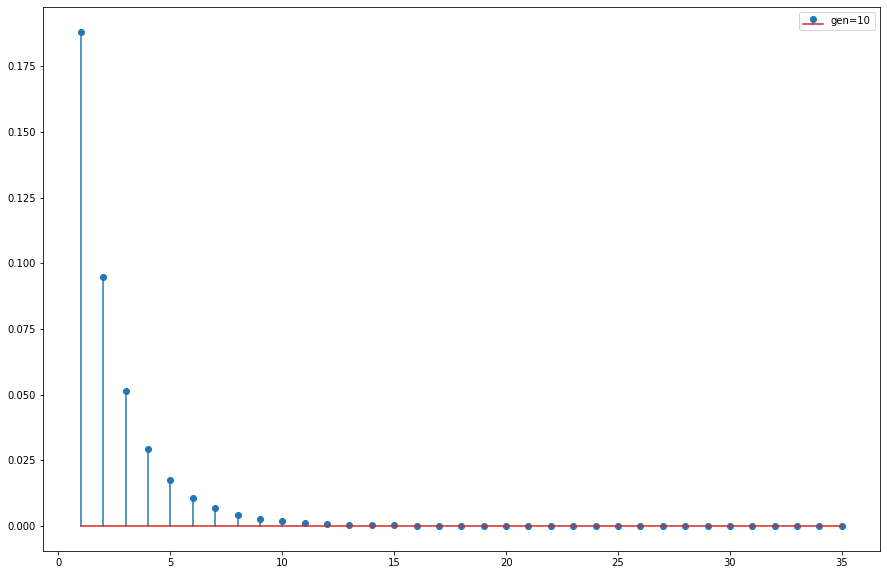

In [376]:
X=np.arange(0,35)
gen=10
Y=[proba_depassement(x,gen, 0.7)-proba_depassement(x+1,gen,0.7) for x in X]
plt.stem(X+1,Y, label="gen={}".format(gen))
print(np.sum(Y))
plt.legend()    

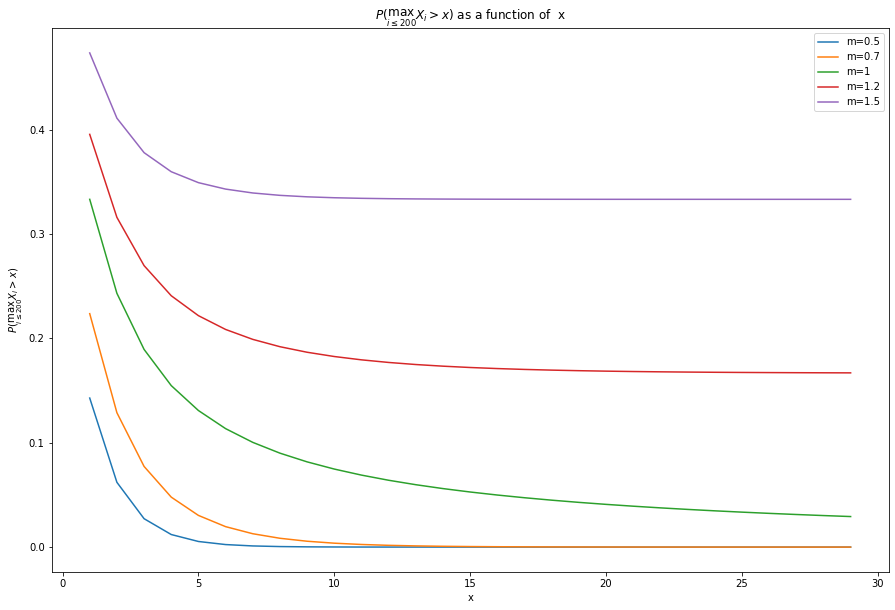

In [22]:
x=10
X=np.arange(1,30)
M=[0.5,0.7,1,1.2,1.5]
for m in M:
    Y=[proba_depassement(x,200,m) for x in X]
    
    plt.plot(X,Y, label="m={}".format(m))
plt.title("$P(\max_{i \leq 200} X_i> x)$ as a function of  x")
plt.ylabel("$P(\max_{i \leq 200} X_i> x)$")
plt.xlabel("x")
plt.legend()
plt.savefig("max")

# 2 environment  Galton-Watson process

In [456]:
p_fav = .8         #probability, at one given generation, to get on average m_fav children per individual
m1 = 2 #m_fav      
m0 = .7
#Computing the probability of death
import itertools
def proba_death_2states(n,m1,m0,p_fav) :
    s = 0
    for i in itertools.product('01', repeat = n) :
        p=1
        q=[1]
        for j in range(n) :
            if i[j] == '1' :
                p = p*p_fav
                q.append(q[-1]/m1)
            else :
                p = p*(1-p_fav)
                q.append(q[-1]/m0)
        s += p*(1 - 1/(np.sum(q)))
    return s


In [7]:

#This part implements the two environments case. The same code structure is kept.



def trajectoire_2states(m0,m1,p_fav,n,pop): #renvoie une trajectoire sans selction pour m=m1
    """Returns a trajectory with the environment [m_0,m1] and p_fav=p_1"""
    X=np.zeros(n)
    X[0]=pop
    for i in range(1,n):
        if np.random.rand()<p_fav:
            if X[i-1]>0:
                X[i]=np.random.negative_binomial(X[i-1],1/(m1+1))
        else:
            if X[i-1]>0:
                X[i]=np.random.negative_binomial(X[i-1],1/(m0+1))
    #print(X)
    return X
def rapport_vraisemblance_2states(m0,m1, p_fav, q0, q1,q_fav, traj): #q0 q1 and q_fav are the new probability kernel paramters 
    """Returns the likelihood ratio for the 2 state kernel"""
    prod=1
    for i in range(1,len(traj)):
        if traj[i-1]>0:
            P=p_fav*sps.nbinom.pmf(traj[i], traj[i-1],1/(m1+1))+(1-p_fav)*sps.nbinom.pmf(traj[i], traj[i-1],1/(m0+1))
            #print("P:",P)
            Q=q_fav*sps.nbinom.pmf(traj[i], traj[i-1],1/(q1+1))+(1-q_fav)*sps.nbinom.pmf(traj[i], traj[i-1],1/(q0+1))
            #print("Q:",Q)
            #print("Le rapport est",P/Q)
            prod *= P/Q
    #print("vraisemblance:", prod)
    return prod
def importance_sampling_2states(n,m0,m1,p_fav,q0,q1,q_fav,pop,event,size=1000):
    """Does an importance sampling with population the probability change m1, and for event """
    trajectoires=[]
    trajectories=[trajectoire_2states(q0,q1,q_fav,n,pop) for i in range(size)]
    liste=[event(traj)*rapport_vraisemblance_2states(m0,m1, p_fav, q0, q1,q_fav, traj) for traj in trajectories]
    #Calcul différent de la variance 
    #liste_var=[event(traj)*rapport_vraisemblance(m,m1,traj)**2 for traj in trajectories]
    return np.mean(liste), np.std(liste)

def mean_log(m0,m1,p_fav):
    """Return the mean lof of the two states, a fundamental quantity which sign determines the regime of the process"""
    return p_fav*np.log(m1)+(1-p_fav)*np.log(m0)

def mean_log_mean(m0,m1,p_fav):
    """Returns another important value defining weak and strong subcritical regimes"""
    
    return p_fav*np.log(m1)*m1+ (1-p_fav)*np.log(m0)*m0
def monte_carlo_naive(n,m0,m1,p_fav,pop,event,size=1000):
    """Does an importance sampling with population the probability change m1, and for event """
    trajectoires=[]
    trajectories=[trajectoire_2states(m0,m1,p_fav,n,pop) for i in range(size)]
    liste=[event(traj) for traj in trajectories]
    #Calcul différent de la variance 
    #liste_var=[event(traj)*rapport_vraisemblance(m,m1,traj)**2 for traj in trajectories]
    return np.mean(liste), np.std(liste)

Det done...
monte_carlo_naive
monte_carlo done...


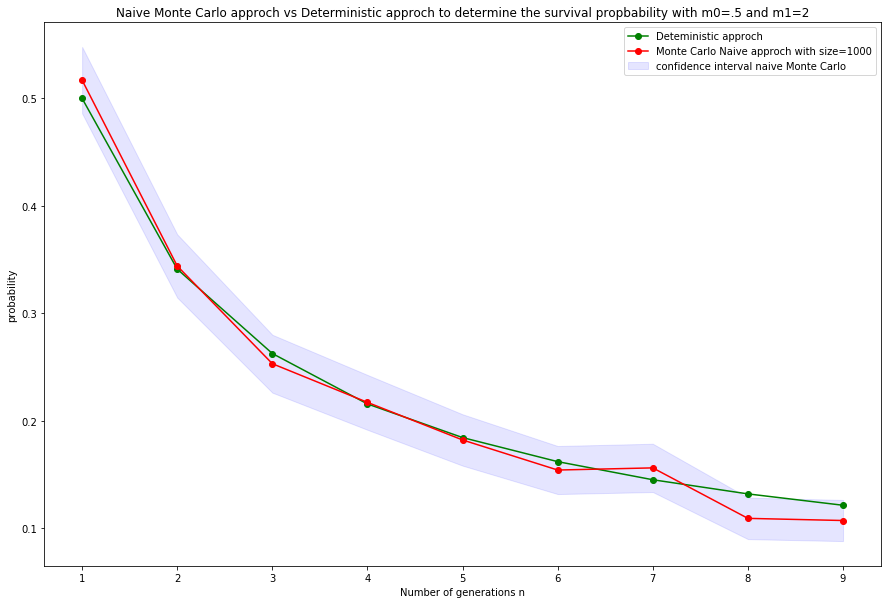

In [490]:
p_fav=1/2
t0=1
t1=10
t2=100
m0=.5
m1=2
N=range(1,10)   #Can't grow further because of exponentiality

Det=[1-proba_death_2states(n,2,.5,1/2) for n in N]
print("Det done...")

monte_carlo=np.array([importance_sampling_2states(n+1,m0,m1,p_fav,m0,m1,p_fav,1,survie,size=1000) for n in N])
monte_carlo_mean=np.array([m[0] for m in monte_carlo])
monte_carlo_std=np.array([m[1] for m in monte_carlo])/np.sqrt(1000)
print("monte_carlo_naive")
""""
#yerr=np.stack([monte_carlo_mean-1.96*monte_carlo_std, monte_carlo_mean+1.96*monte_carlo_std], axis=1)
monte_carlo_imp_sam=np.array([importance_sampling_2states(n+1,m0,m1,p_fav,1,1,p_fav,1,survie,size=1000) for n in N])
monte_carlo_mean_imp_sam=np.array([m[0] for m in monte_carlo_imp_sam])
monte_carlo_std_imp_sam=np.array([m[1] for m in monte_carlo_imp_sam])/np.sqrt(1000)"""

print("monte_carlo done...")
figure,ax=plt.subplots(1)
plt.plot(N,Det, "r-o", color="g", label="Deteministic approch")
plt.plot(N,monte_carlo_mean, "r-o", color="r", label="Monte Carlo Naive approch with size=1000")
#plt.plot(N, monte_carlo_mean_imp_sam,"r-o", color="b", label="Monte Carlo Importance sampling approch" )
ax.fill_between(N, monte_carlo_mean-1.96*monte_carlo_std,monte_carlo_mean+1.96*monte_carlo_std, color='b', alpha=0.1, label="confidence interval naive Monte Carlo")

plt.xlabel("Number of generations n")
plt.ylabel("probability")
plt.title("Naive Monte Carlo approch vs Deterministic approch to determine the survival propbability with m0=.5 and m1=2")
plt.legend()
plt.savefig("2statefirst")

Deterministic method done...
monte_carlo_naive
monte_carlo IS done...


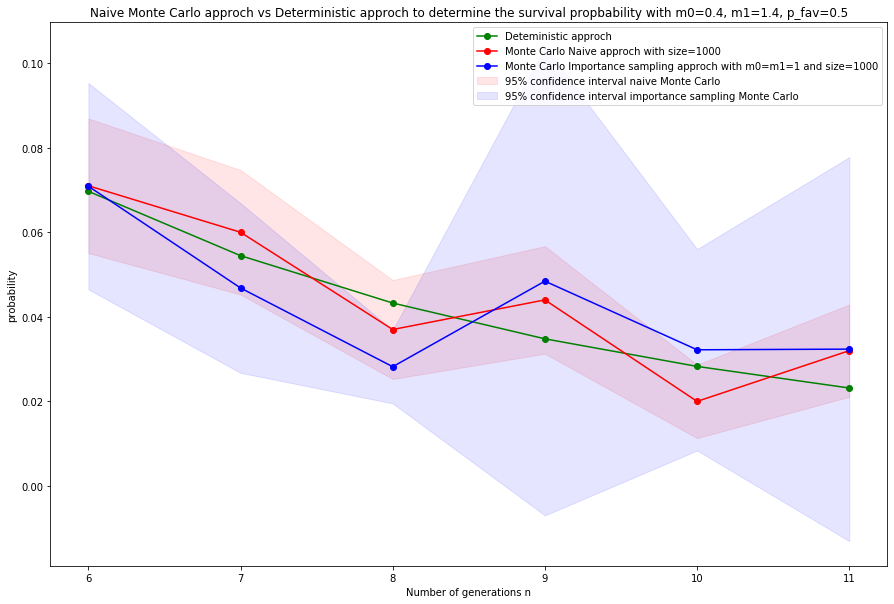

In [653]:
m0=0.4
m1=1.4
p_fav=1/2
N=range(6,12)   #Can't grow further because of exponentiality

Det=[1-proba_death_2states(n,m0,m1,1/2) for n in N]
print("Deterministic method done...")

monte_carlo=np.array([importance_sampling_2states(n+1,m0,m1,p_fav,m0,m1,p_fav,1,survie,size=1000) for n in N])
monte_carlo_mean=np.array([m[0] for m in monte_carlo])
monte_carlo_std=np.array([m[1] for m in monte_carlo])/np.sqrt(1000)
print("monte_carlo_naive")

#yerr=np.stack([monte_carlo_mean-1.96*monte_carlo_std, monte_carlo_mean+1.96*monte_carlo_std], axis=1)
monte_carlo_imp_sam=np.array([importance_sampling_2states(n+1,m0,m1,p_fav,1,1,p_fav,1,survie,size=1000) for n in N])
monte_carlo_mean_imp_sam=np.array([m[0] for m in monte_carlo_imp_sam])
monte_carlo_std_imp_sam=np.array([m[1] for m in monte_carlo_imp_sam])/np.sqrt(1000)

print("monte_carlo IS done...")
figure,ax=plt.subplots(1)
plt.plot(N,Det, "r-o", color="g", label="Deteministic approch")
plt.plot(N,monte_carlo_mean, "r-o", color="r", label="Monte Carlo Naive approch with size=1000")
plt.plot(N, monte_carlo_mean_imp_sam,"r-o", color="b", label="Monte Carlo Importance sampling approch with m0=m1=1 and size=1000" )
ax.fill_between(N, monte_carlo_mean-1.96*monte_carlo_std,monte_carlo_mean+1.96*monte_carlo_std, color='r', alpha=0.1, label="95% confidence interval naive Monte Carlo")
ax.fill_between(N, monte_carlo_mean_imp_sam-1.96*monte_carlo_std_imp_sam,monte_carlo_mean_imp_sam+1.96*monte_carlo_std_imp_sam, color='b', alpha=0.1, label="95% confidence interval importance sampling Monte Carlo")

plt.xlabel("Number of generations n")
plt.ylabel("probability")
plt.title("Naive Monte Carlo approch vs Deterministic approch to determine the survival propbability with m0={}, m1={}, p_fav={}".format(m0,m1,p_fav))

plt.legend()
#plt.savefig("2statefirst_rarer")


## How do the probabilities of survival vary in the case of $E_{\mu}(log(m))=0$ with different variances?

1
2
10
100


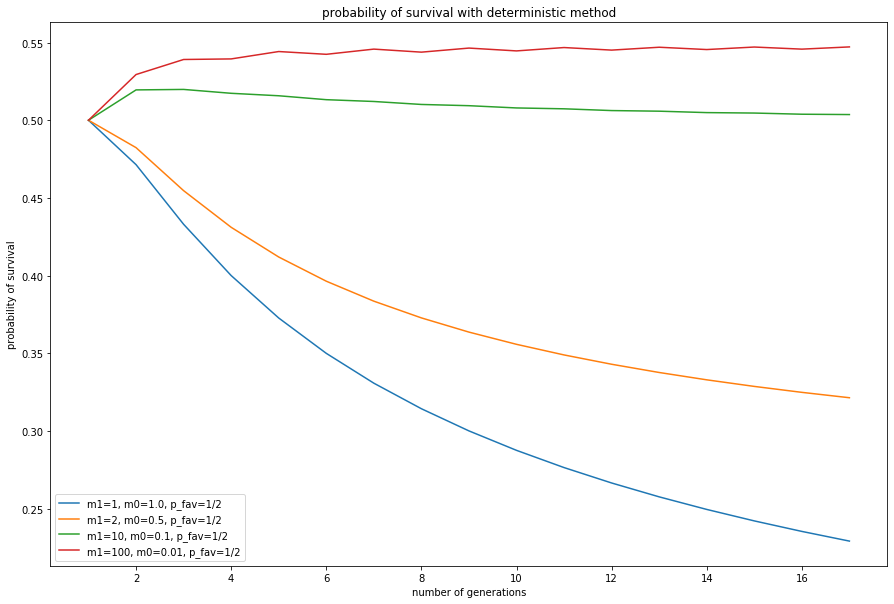

In [589]:

M=[1,2,10,100]  #list of different m1

N=range(1,18)
for i in M:
    m1=i
    m0=1/i
    Determ=[(1-proba_death_2states(n,m0,m1,1/2))*np.sqrt(n) for n in N]
    plt.plot(N,Determ, label="m1={}, m0={}, p_fav=1/2".format(m1,m0))
    print(i)

plt.ylabel ("probability of survival")   
plt.xlabel("number of generations")  
plt.title("probability of survival with deterministic method")
plt.legend()
plt.savefig("equivalentracine_n")

Going further with $n$ to check for the speed:

In [676]:
M=np.arange(1,10)

MC=[]
for i in M:
    MC.append(monte_carlo_naive(1500,1/i,i,p_fav,1,survie,size=1000)[0])
    print("Done {} ...".format(i))



Done 1 ...
Done 2 ...
Done 3 ...
Done 4 ...
Done 5 ...
Done 6 ...
Done 7 ...
Done 8 ...
Done 9 ...


IndexError: list index out of range

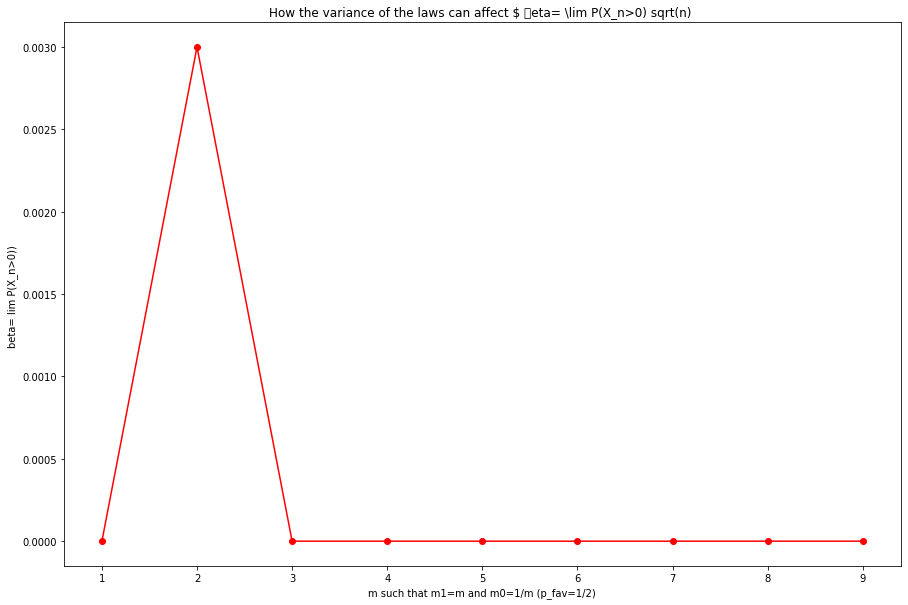

In [677]:
plt.title("How the variance of the laws can affect $ \beta= \lim P(X_n>0) sqrt(n) ")
plt.xlabel("m such that m1=m and m0=1/m (p_fav=1/2)")
plt.ylabel("beta= lim P(X_n>0)*racine(n)) ")
plt.plot(M,MC,"r-o")


In [678]:
preM=np.arange(1,2,0.1) #a second range of m' to illustrates the effect

MC2=[]
for i in preM:
    MC2.append(monte_carlo_naive(1500,1/i,i,1/2,1,survie,1000)[0])
    print("Done {} ...".format(i))

Done 1.0 ...
Done 1.1 ...
Done 1.2000000000000002 ...
Done 1.3000000000000003 ...
Done 1.4000000000000004 ...
Done 1.5000000000000004 ...
Done 1.6000000000000005 ...
Done 1.7000000000000006 ...
Done 1.8000000000000007 ...
Done 1.9000000000000008 ...


In [625]:
monte_carlo_naive(10000,1,1,1/2,1,survie,1000)[0]

0.0

[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  3.  4.  5.  6.  7.  8.  9. ]
[0.00128, 0.00187, 0.00256, 0.00381, 0.00453, 0.00559, 0.00635, 0.00714, 0.007, 0.00761, 0.00729, 0.00385, 0.00148, 0.0004, 0.0002, 6e-05, 2e-05, 1e-05]
[0.         0.19090909 0.36666667 0.53076923 0.68571429 0.83333333
 0.975      1.11176471 1.24444444 1.37368421 1.5        2.66666667
 3.75       4.8        5.83333333 6.85714286 7.875      8.88888889]


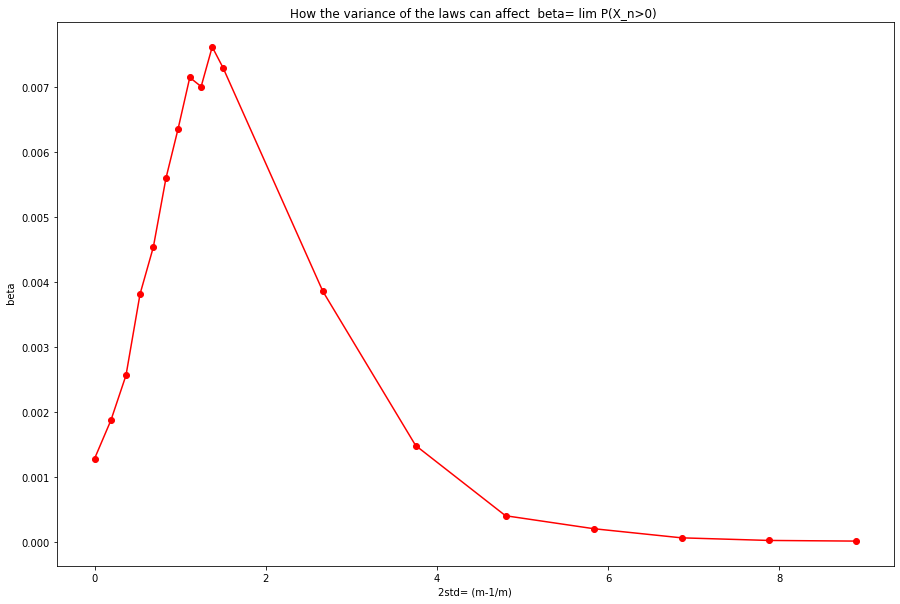

In [627]:
beta=MC2+MC[1:]
M_combine=np.concatenate((preM,np.arange(2,10)))
deviation=M_combine-1/M_combine
print(M_combine)
print(beta)
print(deviation)
plt.plot(deviation,beta, "r-o")
plt.ylabel(" beta")
plt.xlabel("2std= (m-1/m)")
plt.title("How the variance of the laws can affect  beta= lim P(X_n>0) ")
plt.savefig("variance")

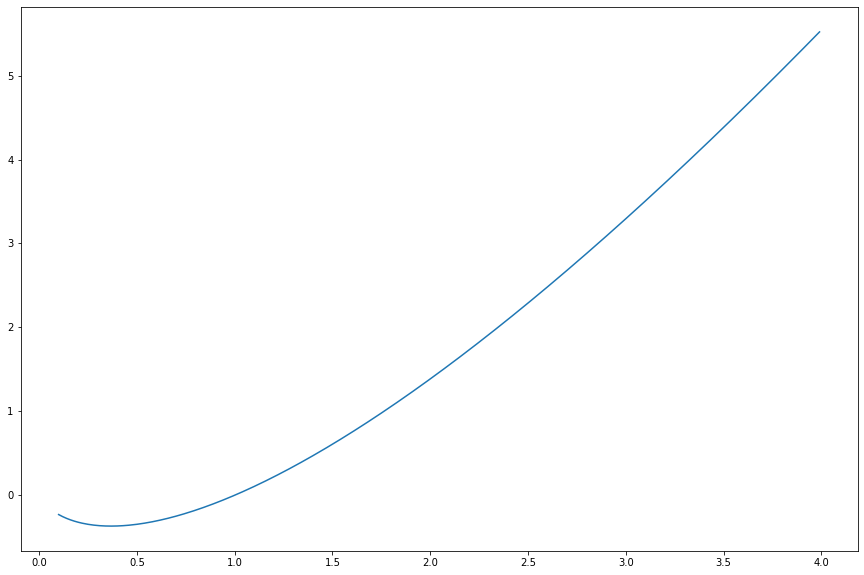

In [656]:
#This function is very important for the branching process


plt.plot(np.arange(.1,4,.01), np.log(np.arange(0.1,4,0.01))*np.arange(0.1,4,.01))

In [11]:
from multiprocessing import Pool, TimeoutError #For parallel computing



m0=0.7
m1=.9

def f(n):
    #print ("I was called with {}".format(n))
    temp=importance_sampling_2states(n+1,m0,m1,p_fav,1,1,1/2,1,survie,size=10000)
    speed=(m1*p_fav+(1-p_fav)*m0)**(-n)
    return temp[0]*speed, temp[1]*speed

if __name__=="__main__":
    N=np.arange(1,30,1)
    proba_survie=[]
    pool = Pool()  
    proba_survie=pool.map(f, N)

Y=np.array(proba_survie)




I was called with 3
I was called with 4
I was called with 1
I was called with 2
I was called with 5
I was called with 7
I was called with 8
I was called with 6
I was called with 9
I was called with 10
I was called with 11
I was called with 12
I was called with 13
I was called with 14
I was called with 15
I was called with 16
I was called with 17
I was called with 18
I was called with 19
I was called with 20
I was called with 21
I was called with 22
I was called with 23
I was called with 24
I was called with 25
I was called with 26
I was called with 27
I was called with 28
I was called with 29


In [49]:
m0=.6
m1=.8
if __name__=="__main__":
   
    pool = Pool()  
    proba_survie2=pool.map(f, N)

I was called with 2
I was called with 5
I was called with 4
I was called with 6
I was called with 7
I was called with 1
I was called with 3
I was called with 8
I was called with 9
I was called with 10
I was called with 11
I was called with 12
I was called with 13
I was called with 14
I was called with 15
I was called with 16
I was called with 17
I was called with 18
I was called with 19
I was called with 20
I was called with 21
I was called with 22
I was called with 23
I was called with 24
I was called with 25
I was called with 26
I was called with 27
I was called with 28
I was called with 29


In [44]:
m0=.5
m1=.9
if __name__=="__main__":
   
    pool = Pool()  
    proba_survie3=pool.map(f, N)

I was called with 5
I was called with 2
I was called with 4
I was called with 6
I was called with 1
I was called with 8
I was called with 3
I was called with 7
I was called with 9
I was called with 10
I was called with 11
I was called with 12
I was called with 13
I was called with 14
I was called with 15
I was called with 16
I was called with 17
I was called with 18
I was called with 19
I was called with 20
I was called with 21
I was called with 22
I was called with 23
I was called with 24
I was called with 25
I was called with 26
I was called with 27
I was called with 28
I was called with 29


[0.33210332103321005, 0.5061361148368219, 0.6149175947940348, 0.6948858484831587, 0.7612961681979681, 0.8207951354321552, 0.8764151848023954, 0.9296372357316888, 0.9812552168634043, 1.0317414476572222, 1.0814033754750476, 1.1304533752876749, 1.1790423475844096, 1.2272779934069311, 1.2752362287699543, 1.3229691455906805, 1.3705109270172826, 1.4178823587255533, 1.4650942884253721, 1.5121502707457197, 1.5590485789139619, 1.6057837281592295, 1.652347626426512, 1.6987304429467163, 1.744921264207684, 1.790908589841865, 1.836680707600331, 1.882225976408365, 1.9275330389849374, 1.9725909799286225, 2.017389441189542, 2.0619187039538356, 2.106169743864216, 2.1501342649835458, 2.1938047168086454, 2.237174297753946, 2.280236947933982, 2.3229873335302993, 2.3654208246791937]
39


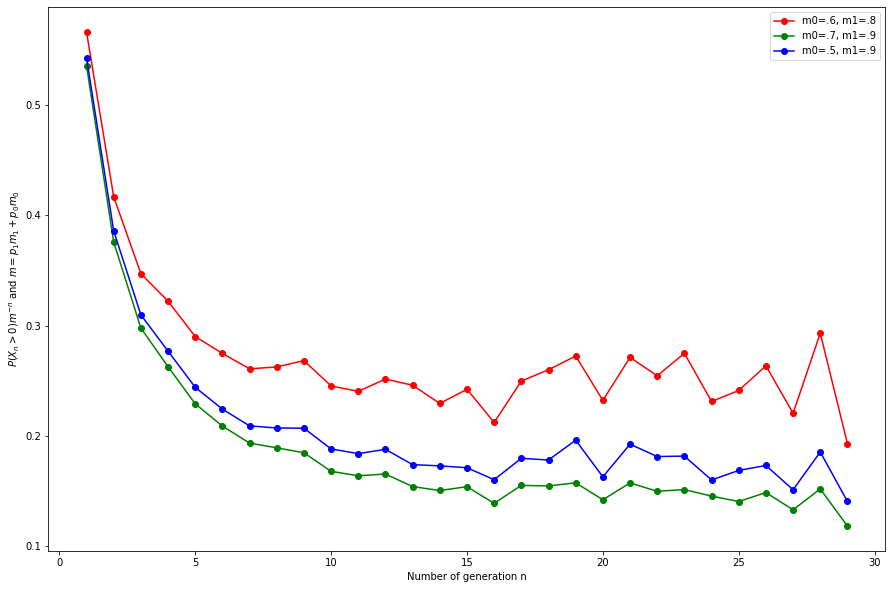

In [50]:
print(Y)
means2=[y[0] for y in proba_survie2]
means1=[y[0] for y in proba_survie]
means3=[y[0] for y in proba_survie3]
print(len(Y))
fig,ax=plt.subplots(1)

#ax.fill_between(N,means-1.96*std,means+1.96*std, color="b", alpha=0.1 )
plt.plot(N,means2, "r-o", label="m0=.6, m1=.8", color="red")
plt.plot(N,means1, "r-o", label="m0=.7, m1=.9", color="green")
plt.plot(N,means3, "r-o", label="m0=.5, m1=.9", color="blue")
plt.xlabel("Number of generation n")
plt.ylabel("$P(X_n>0)m^{-n}$ and $m=p_1m_1+p_0m_0$")
plt.legend()
plt.savefig("case_strong_sub_critical")

In [66]:
def right_p(m0,m1):
    p1=np.log(m0)*m0/(np.log(m0)*m0-np.log(m1)*m1)
    return p1, p1*np.log(m1)+(1-p1)*np.log(m0)

print(right_p(0.5,1.1))

def f1(n):
    #print ("I was called with {}".format(n))
    temp=importance_sampling_2states(n+1,.5,1.1,right_p(m0,m1)[0],1,1,1/2,1,survie,size=100000)
    speed=(m1*p_fav+(1-p_fav)*m0)**(-n)*np.sqrt(n)
    return temp[0]*speed, temp[1]*speed

if __name__=="__main__":
    N=np.arange(1,30,1)
    proba_survie=[]
    pool = Pool()  
    proba_survie_intermediate=pool.map(f, N)




(0.7677497491071917, -0.08780923995855817)
I was called with 5
I was called with 1
I was called with 3
I was called with 4
I was called with 6
I was called with 2
I was called with 8
I was called with 7
I was called with 9
I was called with 10
I was called with 11
I was called with 12
I was called with 13
I was called with 14
I was called with 15
I was called with 16
I was called with 17
I was called with 18
I was called with 19
I was called with 20
I was called with 21
I was called with 22
I was called with 23
I was called with 24
I was called with 25
I was called with 26
I was called with 27
I was called with 28
I was called with 29


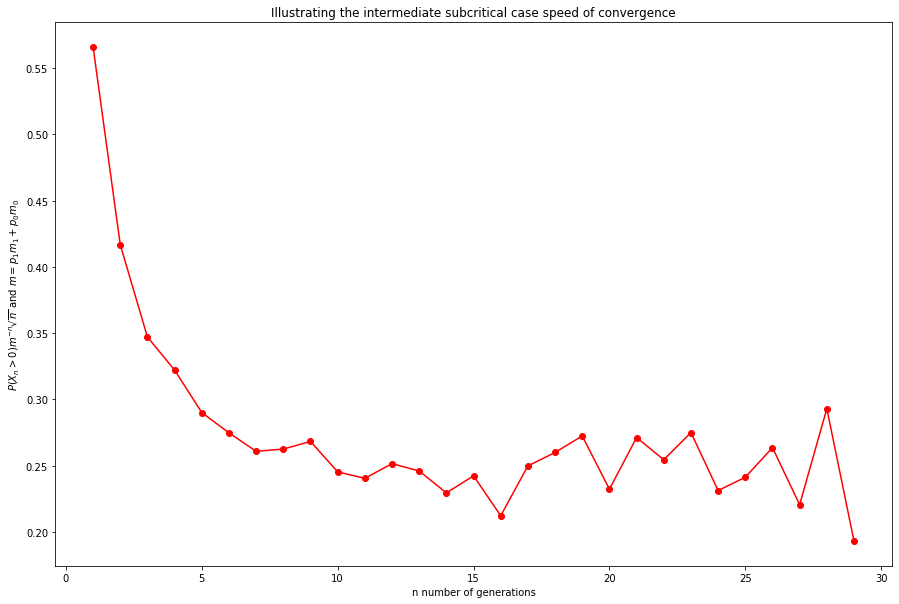

In [69]:
Y=[y[0] for y in proba_survie_intermediate]
plt.plot(N,Y, "r-o", label="An intermediate subcritical case with m0=.5, m1=1.1 and $p_fav \simeq 0.76$")
plt.title("Illustrating the intermediate subcritical case speed of convergence")
plt.xlabel("n number of generations")
plt.ylabel("$P(X_n>0)m^{-n} \sqrt{n}$ and $m=p_1m_1+p_0m_0$")
plt.savefig("inter_subcritical")